# INTRODUCTION

The aim of this project is to analyze relationships between demographic, lifestyle and medical variables associated with diabetes. These factors include aspects such as **`age`**, **`gender`**, **`body mass index (BMI)`**, **`hypertension`**, **`heart disease`**, **`smoking history`**, **`HbA1c level`**, and **`blood glucose level`**. Followed by constructing a Bayesian network to model probabilistic relationships between risk factors and diabetes diagnosis. Use Bayesian inference to predict the likelihood of diabetes under different patient conditions. And finally compare predicted diabetes outcomes with actual diagnoses to evaluate model performance.

### <b><span style='color:purple'>|</span> Variables</b>

<br>


1. **`Age`:** Age is an important factor in predicting diabetes risk. As individuals get older, their risk of developing diabetes increases. 

2. **`Gender`**: Gender can play a role in diabetes risk, although the effect may vary.

3. **`Body Mass Index (BMI)`:** BMI is a screening measure of body fat based on height and weight that acts as a primary, dose-dependent predictor of type 2 diabetes risk.

4. **`Hypertension`:** Hypertension and diabetes are two common metabolic disorders that often coexist in the same individual. Diabetic hypertension is a condition where chronic high blood sugar and insulin resistance lead to widespread damage, scarring and stiffening of the blood vessels and kidneys.

5. **`Heart Disease`:** Diabetic heart disease refers to a group of conditions such as coronary artery disease and heart failure where long-term effects of high blood sugar damage the heart muscle, nerves and blood vessels. The relationship between heart disease and diabetes is bidirectional, meaning that having one condition increases the risk of developing the other. This is because they share many common risk factors, such as obesity, high blood pressure, and high cholesterol.

6. **`Smoking History`:** Smoking is a modifiable risk factor for diabetes. Smoking can contribute to insulin resistance and impair glucose metabolism. Quitting smoking can significantly reduce the risk of developing diabetes and its complications.

7. **`HbA1c Level`:** HbA1c (glycated hemoglobin) is a blood test measuring the percentage of hemoglobin coated with sugar, which reflects your average blood sugar levels over the past two to three months.

8. **`Blood Glucose Level`:** Blood glucose level refers to the concentration of sugar present in the bloodstream at a given time. Regular monitoring of blood glucose levels is important in the diagnosis and management of diabetes.

<br>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Import Neccessary libraries
import numpy as np 
import pandas as pd 

# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the decimal format
pd.options.display.float_format = "{:.2f}".format

In [ ]:
df = pd.read_csv("/Users/juliana-figueroa/Desktop/DSC-515/diabetes_prediction_dataset.csv")

In [ ]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,No Info,27.32,6.60,80,0
2,Male,28.00,0,0,never,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0
5,Female,20.00,0,0,never,27.32,6.60,85,0
6,Female,44.00,0,0,never,19.31,6.50,200,1
7,Female,79.00,0,0,No Info,23.86,5.70,85,0
8,Male,42.00,0,0,never,33.64,4.80,145,0
9,Female,32.00,0,0,never,27.32,5.00,100,0


In [ ]:
df.shape

(100000, 9)

## Pre-processing

### <b>I <span style='color:pink'>|</span> Missing Values</b> 

In [ ]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


### <b>II <span style='color:pink'>|</span> Handling Duplicates </b> 

In [ ]:
duplicate_rows = df[df.duplicated()]
print("Number of duplicate rows: ", duplicate_rows.shape)

Number of duplicate rows:  (3854, 9)


In [ ]:
df = df.drop_duplicates()

Potential duplicates records were identified. However, because the dataset did not include unique patient identifiers, it could not be confirmed whether these rows represented accidental duplicate records or different individuals sharing identical characteristics. Nevertheless, these were removed to reduce redundancy and possible probability bias in the Bayesian network.

### <b>III <span style='color:pink'>|</span> Distinct Values</b> 

In [ ]:
for column in df.columns:
    num_distinct_values = len(df[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

gender: 3 distinct values
age: 102 distinct values
hypertension: 2 distinct values
heart_disease: 2 distinct values
smoking_history: 6 distinct values
bmi: 4247 distinct values
HbA1c_level: 18 distinct values
blood_glucose_level: 18 distinct values
diabetes: 2 distinct values


In [ ]:
print(df['gender'].unique())

['Female' 'Male' 'Other']


In [ ]:
print(df['gender'].value_counts())

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64


In [ ]:
print(df['smoking_history'].unique())

['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [ ]:
print(df['smoking_history'].value_counts())

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


In [ ]:
# Removing 'Other' values from Gender Column
df = df[df['gender'] != 'Other']

*The 'No Info' smoking category was retained as it may still contain behavioral or clinical signifance, and its percentage in the data is significant. The 'Other' gender category was removed due to extremely low representation of less than 0.02%, and to avoid instability probability estimation during Bayesian network modeling.*

### <b>IV <span style='color:pink'>|</span> Basic Statistics</b> 

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00
mean,41.80,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


### <b><span style='color:purple'>|</span> Key Questions</b>

<br>


1. Which variables appear most associated with `diabetes`?
2. Does `age` increase the probability of `diabetes`?
3. How does `hypertension` and `heart disease` influence `diabetes` risk?
4. Is `smoking history` related to higher `diabetes` probability?
5. What is the probability of `diabetes` given high `HbA1c` and high `blood glucose levels`?
6. What is the probability of `diabetes` for older patients with high `BMI`?
7. Does combining multiple risk factors significantly increase `diabetes` likelihood?
8. Which combinations of variables create the highest `diabetes` risk?

<br>

### <b><span style='color:purple'>|</span> Prediction Questions</b>

<br>

1. Can Bayesian networks support early `diabetes` risk detection?
2. How could probabilistic predictions help medical decision-making?
3. What limitations exist when using Bayesian networks in healthcare diagnosis?

<br>

## Univariate Analysis

### *Gender Variable*

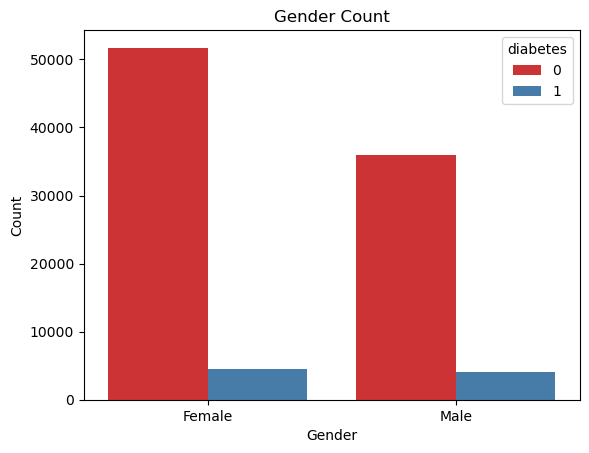

In [ ]:
# Barplot
sns.countplot(x='gender', data=df, palette='Set1', hue='diabetes')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Count')
plt.show()

### *Age Variable*

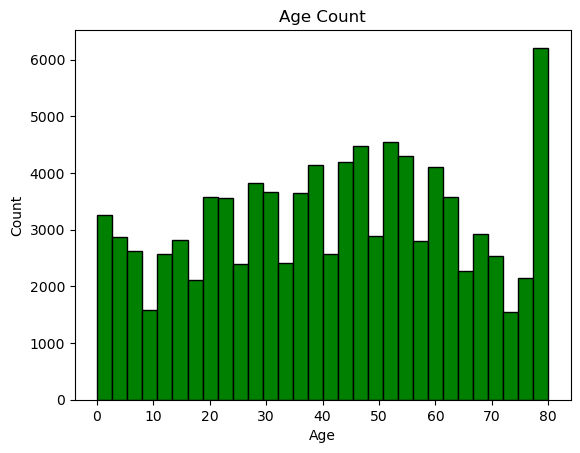

In [ ]:
# Histogram
plt.hist(df['age'], bins=30, edgecolor='black', color='green')
plt.title('Age Count')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### *Binary Variables*

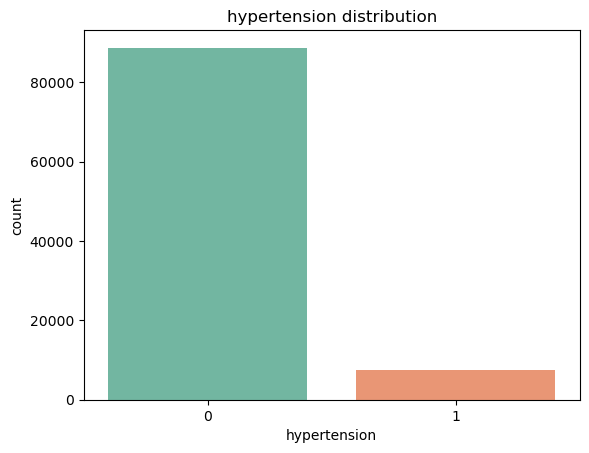

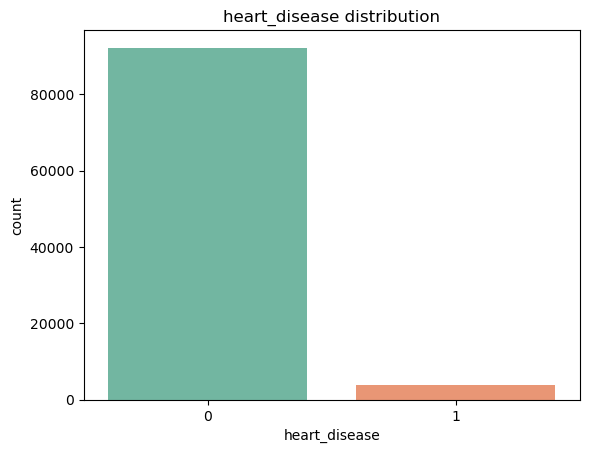

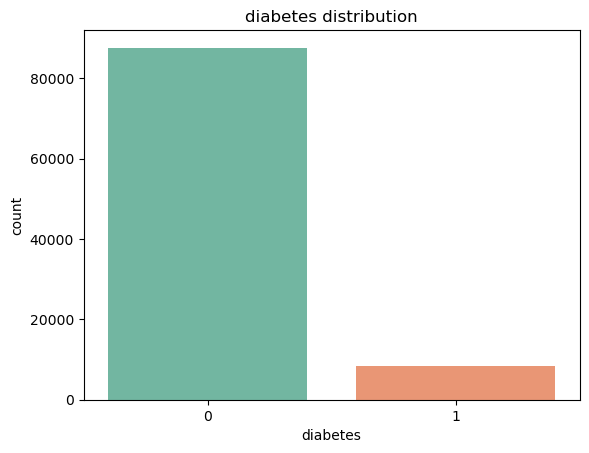

In [ ]:
# Count plots for binary variables
for col in ['hypertension', 'heart_disease', 'diabetes']:
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'{col} distribution')
    plt.show()

### *BMI Variable*

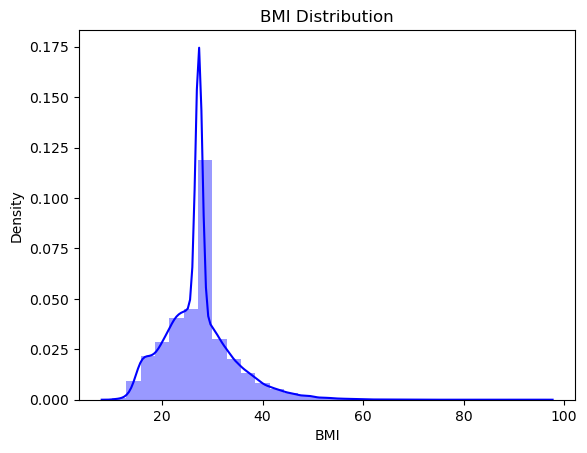

In [ ]:
sns.distplot(df['bmi'], bins=30, color='blue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

### *HbA1c Level Variable*

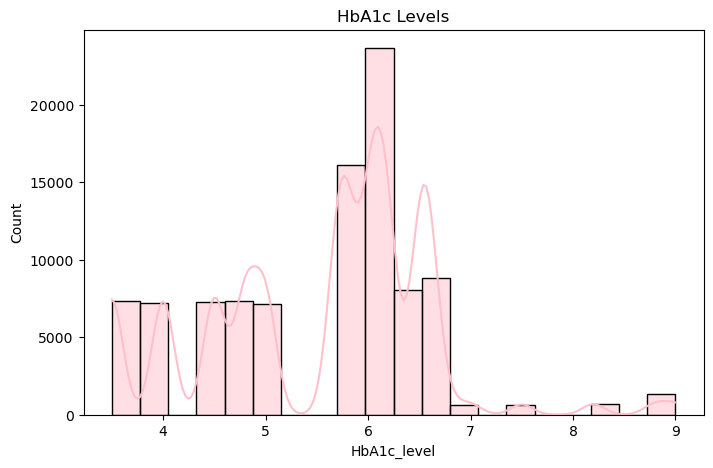

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['HbA1c_level'], bins=20, edgecolor='black', kde=True, color='pink')
plt.title('HbA1c Levels')
plt.show()

### *Blood Glucose Variable*

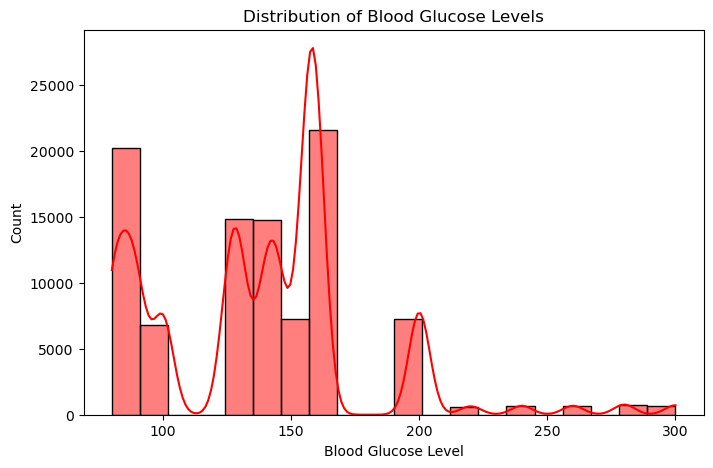

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['blood_glucose_level'], bins=20, kde=True, color='red')

plt.title("Distribution of Blood Glucose Levels")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Count")

plt.show()

### *Smoking History Variable*

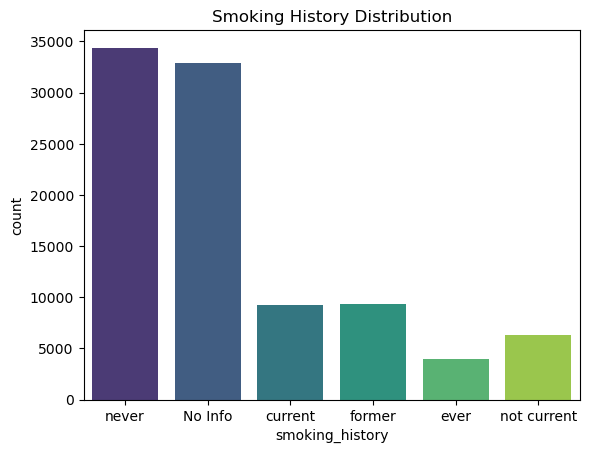

In [ ]:
# Count plot for smoking history
sns.countplot(x='smoking_history', data=df, palette='viridis')
plt.title('Smoking History Distribution')
plt.show()

## Bivariate Analysis

### *Age vs Diabetes*

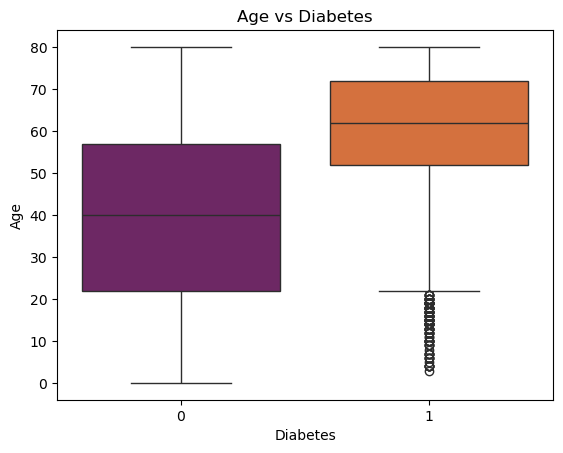

In [ ]:
sns.boxplot(x='diabetes', y='age', data=df, palette='inferno')
plt.title('Age vs Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Age')
plt.show()

### *Smoking History vs Diabetes*

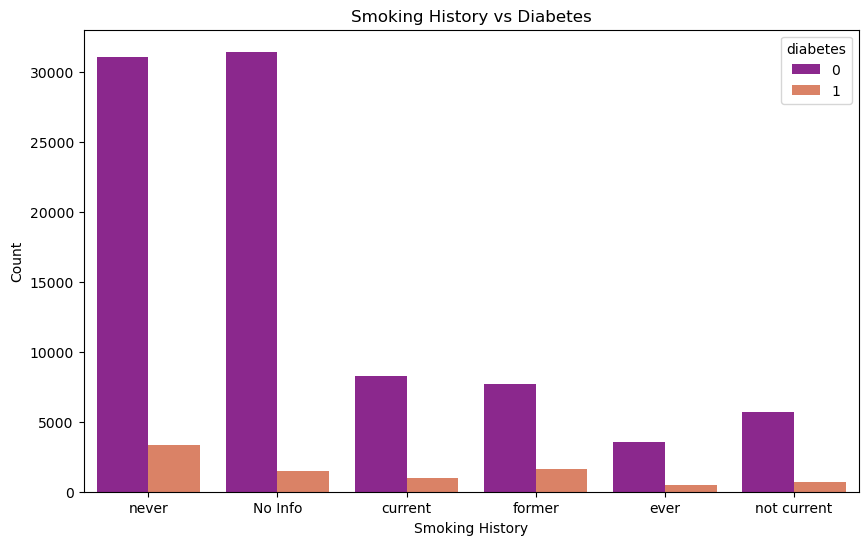

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='smoking_history',hue='diabetes',data=df, palette='plasma')

plt.title("Smoking History vs Diabetes")
plt.xlabel("Smoking History")
plt.ylabel("Count")

plt.show()

### *BMI vs Diabetes*

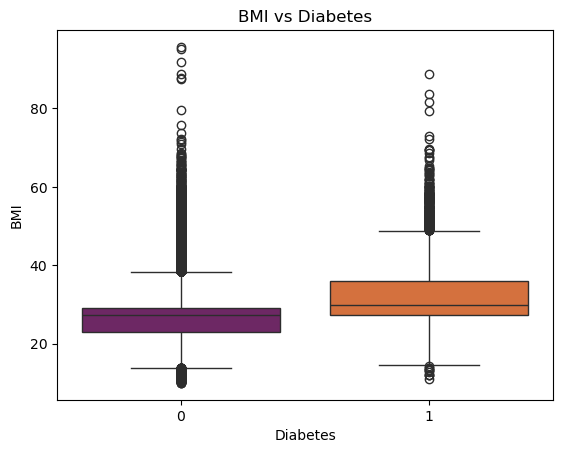

In [ ]:
sns.boxplot(x='diabetes', y='bmi', data=df, palette='inferno')
plt.title('BMI vs Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('BMI')
plt.show()

### *HbA1c vs Diabetes*

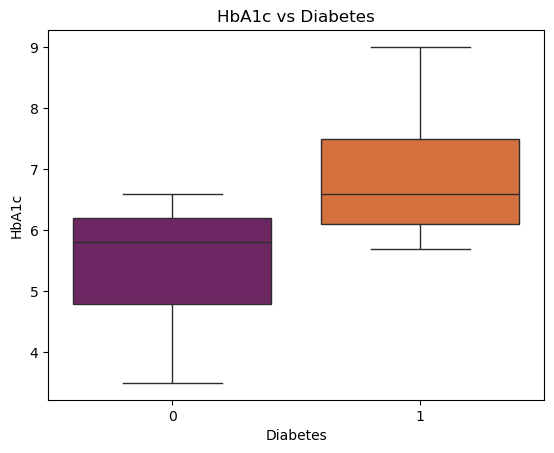

In [ ]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df, palette='inferno')
plt.title('HbA1c vs Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('HbA1c')
plt.show()

### *Blood Glucose Level vs Diabetes*

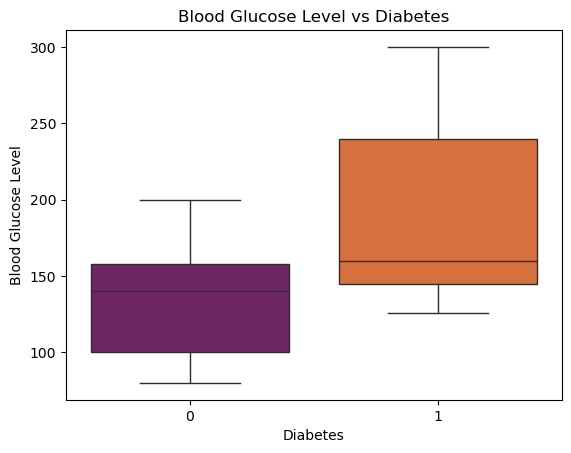

In [ ]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df, palette='inferno')
plt.title('Blood Glucose Level vs Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Blood Glucose Level')
plt.show()

## Multivariate Analysis

### How does hypertension and heart disease influence diabetes risk?

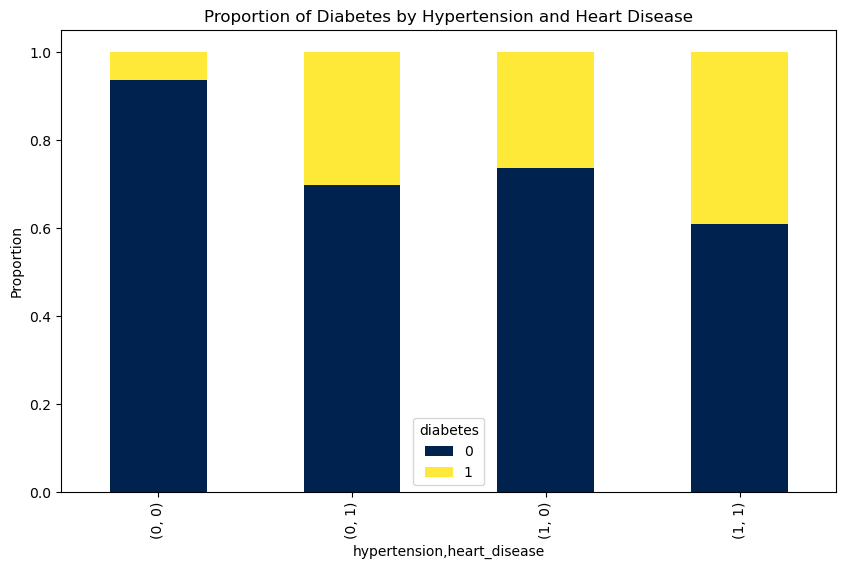

In [ ]:
multi_prop = pd.crosstab(
    [df['hypertension'], df['heart_disease']],
    df['diabetes'],
    normalize='index'
)

multi_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    cmap='cividis'
)

plt.title("Proportion of Diabetes by Hypertension and Heart Disease")
plt.ylabel("Proportion")

plt.show()

### What is the probability of diabetes given high HbA1c and high blood glucose levels?

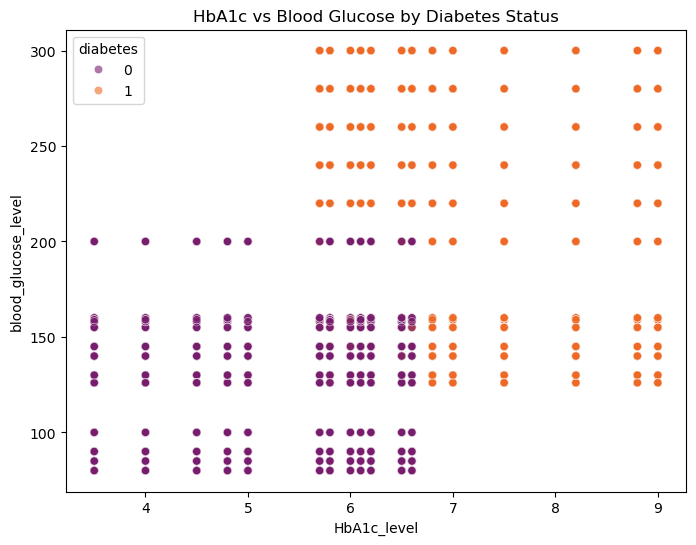

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x='HbA1c_level',y='blood_glucose_level',hue='diabetes',alpha=0.6, palette='inferno')

plt.title("HbA1c vs Blood Glucose by Diabetes Status")
plt.show()

### What is the probability of diabetes for older patients with high BMI?

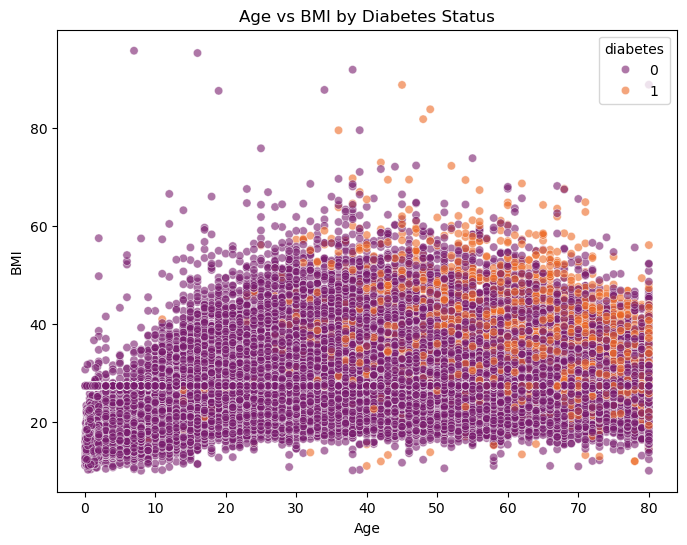

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x='age',y='bmi',hue='diabetes',alpha=0.6, palette='inferno')

plt.title("Age vs BMI by Diabetes Status")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

## Data Preparation

### *Encoding Categorical Variables*

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['smoking_history_encoded'] = le.fit_transform(df['smoking_history'])

In [ ]:
gender_mapping = {
    'Female': 0,
    'Male': 1
}
df['gender_encoded'] = df['gender'].map(gender_mapping)

### *Discretize Continuous Variables*

In [ ]:
# Age
age_bins = [0, 30, 50, 65, 100]

age_labels = [
    'Young',
    'Adult',
    'Older_Adult',
    'Senior'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels
)

In [ ]:
# BMI
bmi_bins = [0, 18.5, 25, 30, 100]

bmi_labels = [
    'Underweight',
    'Normal',
    'Overweight',
    'Obese'
]

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=bmi_bins,
    labels=bmi_labels
)

In [ ]:
# HbA1c
hba1c_bins = [0, 5.7, 6.4, 20]

hba1c_labels = [
    'Normal',
    'Prediabetes',
    'Diabetes_Risk'
]

df['hba1c_category'] = pd.cut(
    df['HbA1c_level'],
    bins=hba1c_bins,
    labels=hba1c_labels
)

In [ ]:
# Blood Glucose
glucose_bins = [0, 100, 400]

glucose_labels = [
    'Normal',
    'High'
]

df['glucose_category'] = pd.cut(
    df['blood_glucose_level'],
    bins=glucose_bins,
    labels=glucose_labels
)

In [ ]:
print(df['hba1c_category'].value_counts())

print(df['glucose_category'].value_counts())

hba1c_category
Normal           44381
Prediabetes      31647
Diabetes_Risk    20100
Name: count, dtype: int64
glucose_category
High      69118
Normal    27010
Name: count, dtype: int64


Although standard medical thresholds were initially considered for blood glucose discretization, exploratory analysis revealed that the dataset contained virtually no observations within the traditional prediabetes glucose range (100–125). The visualization suggested a direct transition from normal glucose levels to elevated diabetic-range values. To better reflect the observed data distribution and improve Bayesian Network stability, blood glucose was simplified into two categories: normal and high.

# <span style="color:purple;">Bayesian Network</span>

In [ ]:
!pip install pandas==2.2.3 statsmodels==0.14.6 pgmpy==1.0.0

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
import networkx as nx

In [ ]:
bn_dataset = df[[
    'gender_encoded',
    'age_group',
    'smoking_history_encoded',
    'bmi_category',
    'hypertension',
    'heart_disease',
    'hba1c_category',
    'glucose_category',
    'diabetes'
]].copy()

In [ ]:
# Network Structure
model = DiscreteBayesianNetwork([
    ('age_group', 'diabetes'),
    ('bmi_category', 'diabetes'),
    ('hypertension', 'diabetes'),
    ('heart_disease', 'diabetes'),
    ('hba1c_category', 'diabetes'),
    ('glucose_category', 'diabetes')
])


## **Bayesian Network Visualization**

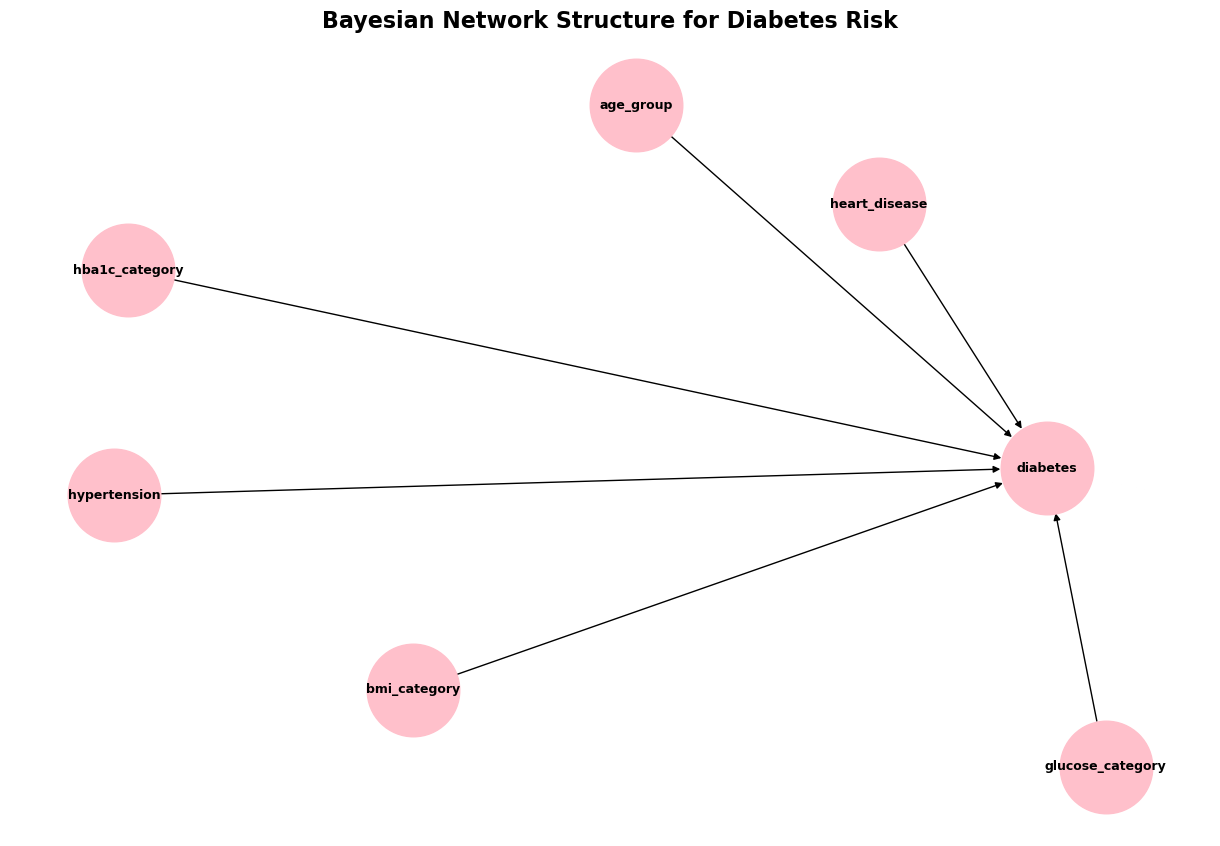

In [ ]:
# Visualize Bayesian Network

plt.figure(figsize=(12,8))

G = nx.DiGraph()
G.add_edges_from(model.edges())

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=4444,
    node_color='pink',
    font_size=9,
    font_weight='bold',
    arrows=True
)

plt.title("Bayesian Network Structure for Diabetes Risk", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# Estimating Conditional Probabilities
model.fit(bn_dataset, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'gender_encoded': 'N', 'age_group': 'O', 'smoking_history_encoded': 'N', 'bmi_category': 'O', 'hypertension': 'N', 'heart_disease': 'N', 'hba1c_category': 'O', 'glucose_category': 'O', 'diabetes': 'N'}


### **Conditional Probabilities Tables**

In [ ]:
for cpd in model.get_cpds():
    print(cpd)
    print("\n")

+------------------------+----------+
| age_group(Adult)       | 0.278119 |
+------------------------+----------+
| age_group(Older_Adult) | 0.212654 |
+------------------------+----------+
| age_group(Senior)      | 0.172104 |
+------------------------+----------+
| age_group(Young)       | 0.337123 |
+------------------------+----------+


+------------------+-----+-----------------------------+
| age_group        | ... | age_group(Young)            |
+------------------+-----+-----------------------------+
| bmi_category     | ... | bmi_category(Underweight)   |
+------------------+-----+-----------------------------+
| glucose_category | ... | glucose_category(Normal)    |
+------------------+-----+-----------------------------+
| hba1c_category   | ... | hba1c_category(Prediabetes) |
+------------------+-----+-----------------------------+
| heart_disease    | ... | heart_disease(1)            |
+------------------+-----+-----------------------------+
| hypertension     | ... | hy

## **Performance Inference**

In [ ]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

### <b>Case I <span style='color:pink'>|</span> High HbA1c + High Glucose</b> 

In [ ]:
result1 = inference.query(variables=['diabetes'],evidence={
        'hba1c_category': 'Diabetes_Risk',
        'glucose_category': 'High'
    }
)

print(result1)

+-------------+-----------------+
| diabetes    |   phi(diabetes) |
+=============+=================+
| diabetes(0) |          0.7304 |
+-------------+-----------------+
| diabetes(1) |          0.2696 |
+-------------+-----------------+


### <b>Case II <span style='color:pink'>|</span> Older Adult + Obese</b> 

In [ ]:
result2 = inference.query(variables=['diabetes'],evidence={
        'age_group': 'Older_Adult',
        'bmi_category': 'Obese'
    }
)

print(result2)

+-------------+-----------------+
| diabetes    |   phi(diabetes) |
+=============+=================+
| diabetes(0) |          0.8194 |
+-------------+-----------------+
| diabetes(1) |          0.1806 |
+-------------+-----------------+


### <b>Case III <span style='color:pink'>|</span> High Glucose + Hypertension</b> 

In [ ]:
result3 = inference.query(variables=['diabetes'],evidence={
        'glucose_category': 'High',
        'hypertension': 1
    }
)

print(result3)

+-------------+-----------------+
| diabetes    |   phi(diabetes) |
+=============+=================+
| diabetes(0) |          0.7799 |
+-------------+-----------------+
| diabetes(1) |          0.2201 |
+-------------+-----------------+


### <b>Case IV <span style='color:pink'>|</span> Low-Risk Patient</b> 

In [ ]:
result4 = inference.query(variables=['diabetes'],evidence={
        'age_group': 'Young',
        'bmi_category': 'Normal',
        'glucose_category': 'Normal',
        'hba1c_category': 'Normal',
        'hypertension': 0,
        'heart_disease': 0
    }
)

print(result4)

+-------------+-----------------+
| diabetes    |   phi(diabetes) |
+=============+=================+
| diabetes(0) |          1.0000 |
+-------------+-----------------+
| diabetes(1) |          0.0000 |
+-------------+-----------------+


### <b>Case V <span style='color:pink'>|</span> High-Risk Patient</b> 

In [ ]:
result5 = inference.query(variables=['diabetes'],evidence={
        'age_group': 'Senior',
        'bmi_category': 'Obese',
        'glucose_category': 'High',
        'hba1c_category': 'Diabetes_Risk',
        'hypertension': 1,
        'heart_disease': 1
    }
)

print(result5)

+-------------+-----------------+
| diabetes    |   phi(diabetes) |
+=============+=================+
| diabetes(0) |          0.2464 |
+-------------+-----------------+
| diabetes(1) |          0.7536 |
+-------------+-----------------+


### <b>Case VI <span style='color:pink'>|</span> High HbA1c + High Glucose + Senior</b> 

In [ ]:
result6 = inference.query(variables=['diabetes'],evidence={
        'hba1c_category': 'Diabetes_Risk',
        'glucose_category': 'High',
        'age_group': 'Senior'
    }
)

print(result6)

+-------------+-----------------+
| diabetes    |   phi(diabetes) |
+=============+=================+
| diabetes(0) |          0.4808 |
+-------------+-----------------+
| diabetes(1) |          0.5192 |
+-------------+-----------------+


# **Generate Predictions**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

inference = VariableElimination(model)

# Store predictions
y_true = []
y_pred = []

# Loop through dataset
for _, row in bn_dataset.iterrows():

    evidence = {
        'age_group': row['age_group'],
        'hypertension': row['hypertension'],
        'heart_disease': row['heart_disease'],
        'bmi_category': row['bmi_category'],
        'hba1c_category': row['hba1c_category'],
        'glucose_category': row['glucose_category'],
    }

    # Predict diabetes probability
    result = inference.query(variables=['diabetes'],evidence=evidence)

    # Probability of diabetes = 1
    prob_diabetes = result.values[1]

    # Convert probability into prediction
    prediction = 1 if prob_diabetes >= 0.5 else 0

    # Store actual and predicted values
    y_true.append(row['diabetes'])
    y_pred.append(prediction)

### <b><span style='color:purple'>|</span> Confusion Matrix</b>

**<mark style="background-color:pink;color:white;border-radius:5px;opacity:1.0">Confusion matrix</mark>** is used to visualize the performance of the model. It shows the true positive, true negative, false positive, and false negative predictions of the model.

<br>

#### **<span style='color:pink'>Accuracy:</span>**

Accuracy measures the overall correctness. It is defined by the sum of the true positives (TP) and true negatives (TN) divided by the sum TP, TN, FP and FN.

<p class="formulaDsp">
\[ Accuracy = \frac{TP + TN}{TP + TN + FP + FN} \]
</p>
<br>

#### **<span style='color:pink'>Precision:</span>**

Precision is a measure of how reliable positive diabetes predictions are. It is defined as the number of true positives (TP) divided by the sum of true positives (TP) and false positives (FP).

<p class="formulaDsp">
\[ Precision = \frac{TP}{TP + FP} \]
</p>

#### **<span style='color:pink'>Recall:</span>**

Recall (or Sensitivity) is a measure of how well the model identifies actual diabetes cases. It is defined as the number of true positives (TP) divided by the sum of true positives (TP) and false negatives (FN).

<br>

<p class="formulaDsp">
\[ Recall = \frac{TP}{TP + FN} \]
</p>

#### **<span style='color:pink'>F1-Score:</span>**


The F1 score is the harmonic mean of Precision and Recall and tries to find the balance between precision and recall. It is defined as 2 times the product of precision and recall divided by the sum of precision and recall.

<br>

<p class="formulaDsp">
\[ F1 Score = \frac{2 * Precision * Recall}{Precision + Recall} \]
</p>

<br> 

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9269827729693741
Precision: 0.6531295792338287
Recall: 0.3678377741098797


In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     87646
           1       0.65      0.37      0.47      8482

    accuracy                           0.93     96128
   macro avg       0.80      0.67      0.72     96128
weighted avg       0.92      0.93      0.92     96128



#### **Confusion Matrix Visualization**

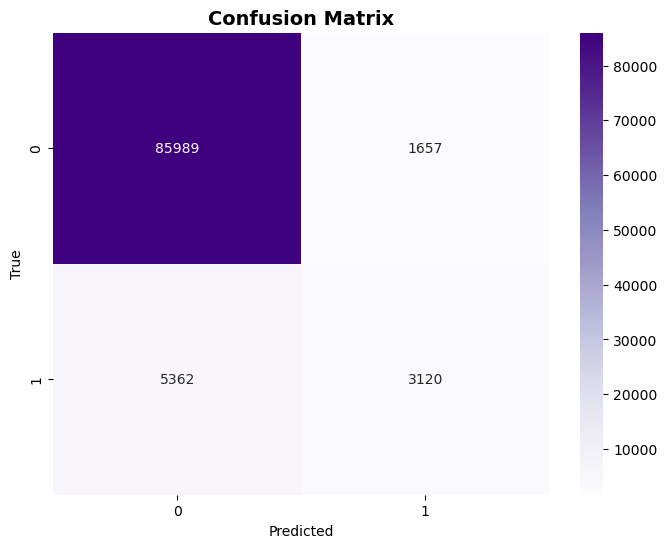

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# **Final Insights**

### **Summary of Key Findings from Visualizations**


The exploratory visualizations revealed several important relationships between health factors and diabetes risk. The multivariate analysis comparing hypertension and heart disease showed that diabetes prevalence increased when either condition was present, and the highest proportion of diabetes cases appeared among individuals with both hypertension and heart disease. This suggests that cardiovascular-related conditions are associated with elevated diabetes risk.

The HbA1c versus blood glucose scatterplot showed a clear separation between diabetic and non-diabetic individuals. Patients with higher HbA1c values and elevated blood glucose levels were much more likely to belong to the diabetes-positive class. In contrast, lower HbA1c and glucose values clustered heavily among non-diabetic individuals. This indicates that HbA1c and blood glucose are among the strongest predictors in the dataset.

The age versus BMI visualization demonstrated that diabetes cases were more concentrated among older individuals and those with higher BMI levels. While non-diabetic cases appeared across all ages and BMI ranges, diabetic observations became denser in overweight and obese populations, especially in middle-aged and senior groups. However, age showed a bigger probability of risk to get diabetes than BMI itself.

### **Insights from Bayesian Network**

The Bayesian Network modeled probabilistic relationships between diabetes and several contributing variables, including age group, BMI category, hypertension, heart disease, HbA1c category, and glucose category. The network structure indicated that these factors directly influenced the probability of diabetes.

Inference results showed how risk changed under different conditions:

Individuals with high HbA1c and high glucose had a substantially increased probability of diabetes.
Older adults with obesity also showed elevated diabetes probability compared to baseline individuals.
Patients with high glucose and hypertension demonstrated greater diabetes likelihood than healthier populations.
The low-risk patient profile (young, normal BMI, normal glucose, normal HbA1c, no hypertension, and no heart disease) resulted in nearly zero predicted diabetes probability.
The high-risk patient profile (senior, obese, high glucose, high HbA1c, hypertension, and heart disease) produced the highest diabetes probability, exceeding 75%.

These findings demonstrate how Bayesian Networks can combine multiple risk factors simultaneously and estimate conditional probabilities for medical decision-making.

### **Evaluation of the Classification Report and Confusion Matrix**

The model achieved an overall accuracy of approximately 92.7%, indicating that most predictions were correct. The confusion matrix further showed that the model performed very well at identifying non-diabetic individuals, with a large number of true negatives (85,989) and relatively few false positives (1,657).

However, performance for diabetic cases was weaker. Although precision for diabetes predictions was about 65%, meaning many predicted positives were correct, the recall was only about 36.8%. This means the model failed to identify a significant portion of actual diabetes cases, producing many false negatives (5,362). In medical settings, low recall is concerning because missed diagnoses may delay treatment and worsen patient outcomes.

The classification report confirmed this imbalance. The non-diabetic class achieved excellent performance with high precision, recall, and F1-score, while the diabetic class had a much lower F1-score of approximately 0.47. This suggests the dataset was likely imbalanced, with substantially more non-diabetic observations than diabetic ones.

### **Limitations and Ethical Concerns in Real-World Medical Diagnoses**

Although the Bayesian Network and classification model produced meaningful insights, several limitations and ethical concerns must be considered before applying these systems in real-world healthcare environments.

One major limitation is dataset imbalance. The model contained significantly more non-diabetic than diabetic cases, which contributed to high overall accuracy but poor recall for diabetes detection. In medicine, accuracy alone can be misleading because failing to identify true disease cases may have severe consequences for patients. A model with low sensitivity may overlook individuals who require urgent treatment or monitoring.

Another limitation is the simplification introduced during discretization. Discretization was necessary to construct the Discrete Bayesian Network and improve interpretability and probabilistic reasoning. However, converting continuous medical measurements into categories may reduce some detailed information. Additionally, the dataset imbalance likely contributed more significantly to the model’s lower recall for diabetes prediction.

Ethically, bias is a major concern in medical AI systems. If the training data underrepresents certain demographic groups, the model may perform poorly for those populations. Differences in genetics, healthcare access, socioeconomic conditions, and disease presentation may not be captured equally across all groups. As a result, predictions could unintentionally reinforce healthcare disparities.

Privacy is another important issue. Medical datasets contain highly sensitive personal information, and improper data handling could expose patient identities or medical histories. Strict safeguards, anonymization procedures, and regulatory compliance are essential when developing predictive healthcare systems.

Additionally, probabilistic models should never replace clinical judgment. Bayesian Networks estimate likelihoods based on patterns in historical data, but they cannot fully capture contextual information such as lifestyle, family history, physician expertise, or unusual symptoms. Overreliance on automated predictions may lead clinicians to trust the model excessively, even when human evaluation suggests otherwise.

Finally, transparency and interpretability remain critical. Patients and healthcare professionals must understand how predictions are generated and what factors contribute to risk assessments. Ethical medical AI should support physicians as a decision-assistance tool rather than functioning as a fully autonomous diagnostic system.

#### **References**

Pannmie. (2023). Diabetes: EDA | Random Forest + HP. Kaggle. https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp 